# Iterative Quantum Phase Estimation

In this tutorial, we will go over iterative quantum phase estimation and compare it to the vanilla quantum phase estimation algorithm.

Quantum phase estimation is a core component in quantum algorithm/application development. Iterative quantum phase estimation (IQPE), presented in "Semiclassical Fourier Transform for Quantum Computation" ([arXiv:quant-ph/9511007](https://arxiv.org/abs/quant-ph/9511007)), estimates the phase one bit at a time, starting from the least significant bit. Importantly, IQPE uses a single phase qubit; it is used to estimate each bit of the true phase and then reset for the next iteration, making this variant cheaper in qubit count. 
For a nice figure of the IQPE, we refer the readers to Fig. 2 of "Arbitrary accuracy iterative phase estimation algorithm as a two qubit benchmark" ([arXiv:quant-ph/0610214](https://arxiv.org/abs/quant-ph/0610214)).

For early generation QPUs, where they may often by qubit-constrained, iterative QPE may be preferred to the other versions.
In fact, quantum applications like phase estimating Fermi-Hubbard using plaquette Trotterization, presented in "Early fault-tolerant simulations of the Hubbard model" ([arXiv:2012.09238](https://arxiv.org/abs/2012.09238)), assume this version of QPE.

In [1]:
from psiqdk.workbench import QPU, QUFixed, Qubits, Qubrick
from psiqdk.algorithms import IterativeQPE, QPE

import matplotlib.pyplot as plt
import numpy as np

In this tutorial, we will demonstrate the IQPE implementation and compare it to vanilla QPE using a simple phase gate as the unitary $U$. 

In [2]:
class SimplePhaseUnitary(Qubrick):
    """A Qubrick wrapper for the phase gate for debugging QPE routines.

    Allows for exact eigenphases to be implemented in QPE.
    """

    def __init__(self, phase: float, **kwargs):
        """Initialize the Qubrick.

        Args:
            phase: Phase, as a fraction of 2π.
        """
        if phase > 1 or phase < 0:
            raise ValueError('Phase should be between 0 and 1.')
        self.phase = phase
        super().__init__(**kwargs)

    def _compute(self, psi: Qubits, ctrl: Qubits | int = 0):
        """Apply the Rz gate.

        Args:
            psi: State register for the computation.
            ctrl: Register to control the unitary on. Defaults to ``0``.
        """
        theta = 360 * self.phase
        psi.phase(theta, cond=ctrl)

## Phase is exactly representable

To start with, we'll consider the scenario in which the true phase is exactly representable with the precision qubits you've allocated for your QPE. Then both IQPE and vanilla QPE will return the correct phase deterministically. The following example demonstrates this.

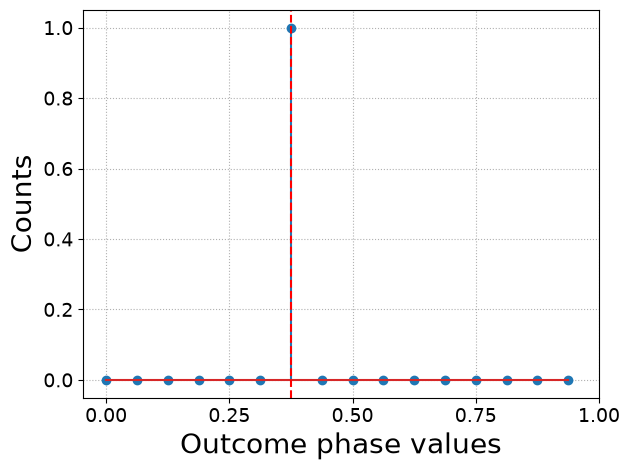

In [3]:
bits_of_precision = 4
phase = 1/4 + 1/8  # exactly representable using 4 bits

def run_iterative_qpe_example():
    n_trials = 100
    # Frequencies of possible QPE outcomes (represented as floats)
    outcomes = {ind / (1 << bits_of_precision): 0.0 for ind in range(1 << bits_of_precision)}

    qpu = QPU()
    for trial in range(n_trials):
        qpu.reset(2)
        # Use different random seed on each trial but make the entire set deterministic
        qpu.random_seed(trial)
        psi = Qubits(1, "psi", qpu)    # the eigenstate register
        phase_reg = Qubits(1, "phase_reg", qpu)

        # Initialize the Qubricks
        unitary = SimplePhaseUnitary(phase=phase)
        qpe = IterativeQPE(bits_of_precision=bits_of_precision, unitary=unitary)

        # Prepare the eigenstate |1⟩ (hardcoded)
        psi.x()

        # Apply the QPE
        qpe.compute(psi, phase_reg)

        # Read out the resulting phase as a little-endian list of bits
        res_bits = qpe.get_classical_result('phase_readout')
        res_int = sum([bit * 2 ** ind for ind, bit in enumerate(res_bits)]) 
        outcomes[res_int / (1 << bits_of_precision)] += 1 / n_trials

    return outcomes

def plot_qpe_outcomes(outcomes):
    plt.stem(list(outcomes.keys()), list(outcomes.values()))

    plt.axvline(phase, color='r', linestyle='--')
    plt.grid(linestyle=':')

    plt.xlabel('Outcome phase values', fontsize=20)
    plt.ylabel('Counts', fontsize=20)

    plt.xticks(ticks=[0.0, 0.25, 0.5, 0.75, 1.0], fontsize=14)
    plt.yticks(fontsize=14)

    plt.tight_layout()

iqpe_frequencies = run_iterative_qpe_example()
plot_qpe_outcomes(iqpe_frequencies)

We can compare the iterative QPE results with those produced by vanilla QPE. You can see that the two plots match exactly.

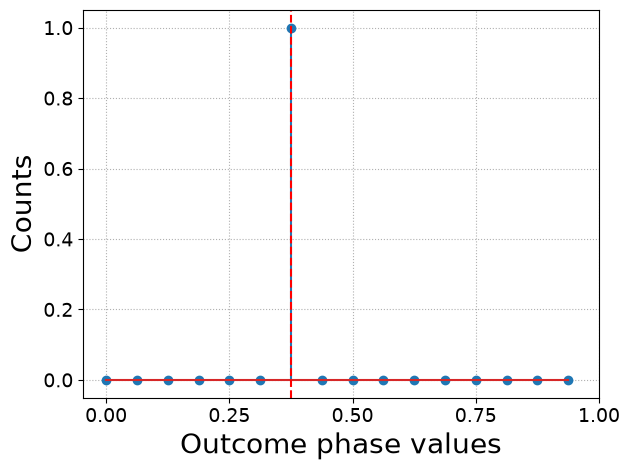

In [4]:
def run_vanilla_qpe_example():
    qpu = QPU(num_qubits=bits_of_precision + 1)
    qpu.random_seed(1)
    psi = Qubits(1, "psi", qpu)    # the eigenstate register
    phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qpu)

    # Initialize the Qubricks
    unitary = SimplePhaseUnitary(phase=phase)
    qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)

    # Prepare the eigenstate |1⟩ (hardcoded)
    psi.x()

    # Apply the QPE
    qpe.compute(psi, phase_reg)

    # Instead of sampling, peek at measurement probabilities
    probabilities = {
        ind / (1 << bits_of_precision): phase_reg.peek_read_probability(ind) 
        for ind in range(1 << bits_of_precision)
    }
    return probabilities

qpe_probabilities = run_vanilla_qpe_example()
plot_qpe_outcomes(qpe_probabilities)

## Phase is not representable exactly

Now, let's see what happens if the true phase is not representable exactly with the precision qubits you've allocated for your QPE. Then IQPE will return the nearest representable phase with high probability. The following example demonstrates this.

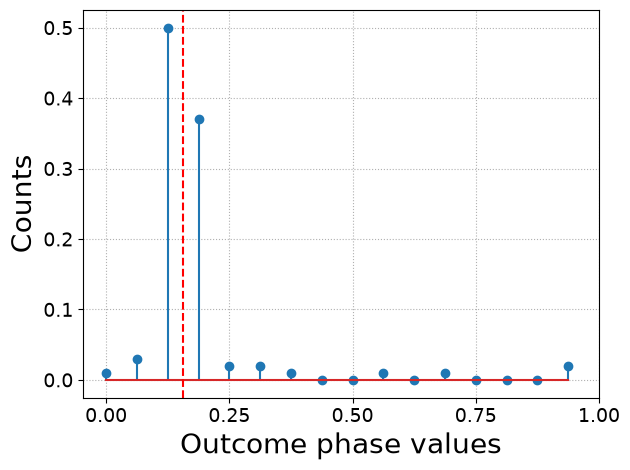

In [5]:
bits_of_precision = 4
phase = 5 / 32

iqpe_frequencies = run_iterative_qpe_example()
plot_qpe_outcomes(iqpe_frequencies)

Let's compare the histogram above to the result of the vanilla QPE:

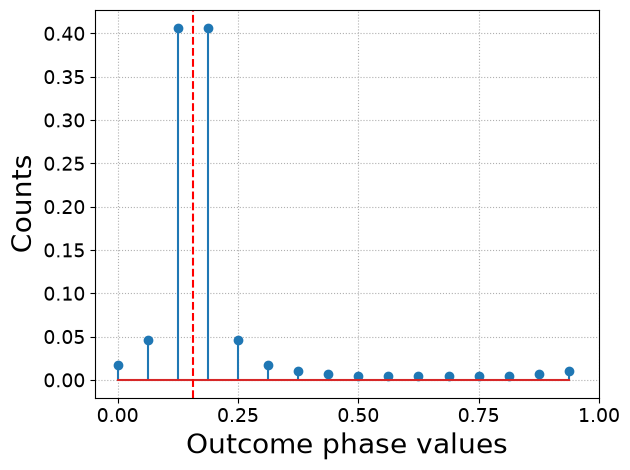

In [6]:
qpe_probabilities = run_vanilla_qpe_example()
plot_qpe_outcomes(qpe_probabilities)

In fact, the probability of getting one of the two representable values nearest to the correct one should be comparable for both versions of QPE. The true phase we used in the example above is halfway between two representable values, which means the success probability (of landing on any of them) should approach $8/\pi^2$ as we take more shots and with more bits of precision. Let's verify this.

In [7]:
iqpe_success_freq = iqpe_frequencies[0.125] + iqpe_frequencies[0.1875]
qpe_success_prob = qpe_probabilities[0.125] + qpe_probabilities[0.1875]
ideal_success_prob = 8 / np.pi ** 2
print(f"IQPE success frequency = {iqpe_success_freq}")
print(f"QPE success probability = {qpe_success_prob}")
print(f"Ideal success probability = {ideal_success_prob}")
assert np.isclose(qpe_success_prob, ideal_success_prob, 0.01)

IQPE success frequency = 0.8700000000000003
QPE success probability = 0.813178663436073
Ideal success probability = 0.8105694691387022


> In the examples above, we assumed that the phase was encoded as an unsigned fixed-point number between 0 and 1. An alternative problem formulation relies on encoding the phase as a signed fixed-point number between -1 and 1. In this case, the IQPE algorithm looks identical, the only difference is in processing the output bit string to convert it into a numeric result. IQPE and vanilla QPE will also produce similar results in this case.

## Summary

In this tutorial, we compared iterative quantum phase estimation algorithm - the variant that relies on using a single qubit to read out the phase instead of multiple qubits - with vanilla quantum phase estimation. Both algorithms produced similar results regardless of whether the true phase was representable exactly within the chosen bits of precision or not.

In the next tutorial, we will explore improving QPE results for phases that are not exactly representable, introducing [window functions for QPE](./Window_Functions_for_QPE.ipynb).